In [1]:
from pathlib import Path
import json
from typing import Optional

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import cKDTree

from plant_shape_analysis.dataloaders.trackplant3D import LeafSequencesDataset, PlantSequencesDataset
from plant_shape_analysis.data_preprocessing.detect_leaf_tips_trackplant3D import load_point_cloud_from_txt

%load_ext autoreload
%autoreload 2

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


We now that the [TrackPlant3D dataset](https://github.com/entarot/TrackPlant3D-3D-organ-growth-tracking-framework-for-organ-level-dynamic-phenotyping/tree/main/data) contains point cloud plant sequences coming from the [4D plant registration](https://www.ipb.uni-bonn.de/data/4d-plant-registration/) dataset (which is an ealier unannotated but clean version of the Pheno4D dataset). All maize sequences from TrackPlant3D are derived from the 4D plant registration dataset, and the `tomato2` sequences also come from it.

## Trackplant3D dataset

In [2]:
dataset_path = Path("../data/TrackPlant3D")

### Leaf sequences dataset

We check how many sequences of leaves too have dense ground truth annotations.

In [3]:
leaf_dataset = LeafSequencesDataset(dataset_path, min_timepoints=3)
# leaf_dataset.get_leaf_timeseries_info()

In [4]:
maize_leaf_sequences = [f"{seq['sequence_name']}_leaf{seq["leaf_id"]}" for seq in leaf_dataset.get_timeseries_by_crop("maize")]
tomato_leaf_seq = [f"{seq['sequence_name']}_leaf{seq["leaf_id"]}" for seq in leaf_dataset.get_timeseries_by_crop("tomato2")]

In [5]:
print("Expected amount of leaf sequences with dense GT:")
len(maize_leaf_sequences) + len(tomato_leaf_seq)

Expected amount of leaf sequences with dense GT:


31

In [6]:
print("Expected amount of total leaf point clouds:")
sum([len(seq["timepoints"]) for seq in leaf_dataset.get_timeseries_by_crop("maize")]) + \
sum([len(seq["timepoints"]) for seq in leaf_dataset.get_timeseries_by_crop("tomato2")])

Expected amount of total leaf point clouds:


205

### Whole plant sequences dataset

In [7]:
plant_dataset = PlantSequencesDataset(dataset_path)

In [8]:
def get_trackplant3D_scans_paths(crop: str) -> list[Path]:
    trackplant3D = []
    for name, path in sorted(plant_dataset.get_sequences_by_crop(crop).items(), key=lambda x: x[0]):
        trackplant3D.extend(path)
    return trackplant3D

In [9]:
maize_paths_trackplant3d = get_trackplant3D_scans_paths("maize")
tomato_paths_trackplant3d = get_trackplant3D_scans_paths("tomato2")
len(maize_paths_trackplant3d), len(tomato_paths_trackplant3d)

(26, 27)

## 4D plant registration dataset

In [10]:
base_path = Path("../data/4d_plant_registration_data")

In [11]:
def get_4dplantreg_scans_paths(base_path: Path) -> list[Path]:
    scans_list = []
    for plant in sorted(base_path.iterdir()):
        for seq in sorted(plant.iterdir()):
            scans_list.append(seq)
    return scans_list

In [12]:
maize_paths_4dplantreg = get_4dplantreg_scans_paths(base_path / "maize")
tomato_paths_4dplantreg = get_4dplantreg_scans_paths(base_path / "tomato")
len(maize_paths_4dplantreg), len(tomato_paths_4dplantreg)

(26, 27)

Check that we have the expected amount of plant scans on both datasets

In [13]:
assert len(maize_paths_4dplantreg) == len(maize_paths_trackplant3d)
assert len(tomato_paths_4dplantreg) == len(tomato_paths_trackplant3d)

There are 53 scans in total from 6 plant sequences, with a total of 31 leaf sequences and 205 leaf point clouds

Now we would like to align the scans of TrackPlant3D to their 4D plant registration dataset GT, and propagate the labels accordingly (e.g. via k-NN).

## Align scans across datasets

### Visualize sample scan

In [63]:
# Helper functions
def visualize_point_clouds_side_by_side(pc1, pc2, title1="Source", title2="Target", labels1=None, labels2=None):
    """Visualize two point clouds side by side"""
    fig = plt.figure(figsize=(15, 6))
    
    # First point cloud
    ax1 = fig.add_subplot(121, projection='3d')
    if labels1:  # Has labels/colors
        ax1.scatter(pc1[:, 0], pc1[:, 1], pc1[:, 2], c=labels1, s=1, alpha=0.6, cmap='viridis')
    else:
        ax1.scatter(pc1[:, 0], pc1[:, 1], pc1[:, 2], s=1, alpha=0.6)
    ax1.set_title(title1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Second point cloud
    ax2 = fig.add_subplot(122, projection='3d')
    if labels2:  # Has labels/colors
        ax2.scatter(pc2[:, 0], pc2[:, 1], pc2[:, 2], c=labels2, s=1, alpha=0.6, cmap='viridis')
    else:
        ax2.scatter(pc2[:, 0], pc2[:, 1], pc2[:, 2], s=1, alpha=0.6)
    ax2.set_title(title2)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()


def visualize_point_clouds_together(pc1, pc2, title1="Alignment comparison", legend_labels: list[str, str] = ["Transformed", "Target"]):
    """Visualize two point clouds together"""
    fig = plt.figure(figsize=(15, 6))
    
    # Add point clouds
    ax1 = fig.add_subplot(111, projection='3d')
    ax1.scatter(pc1[:, 0], pc1[:, 1], pc1[:, 2], s=1, alpha=0.6, label=legend_labels[0])
    ax1.scatter(pc2[:, 0], pc2[:, 1], pc2[:, 2], s=1, alpha=0.6, marker="^", label=legend_labels[1])
    ax1.set_title(title1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    plt.tight_layout()
    plt.show()

In [15]:
scan_id = 0
source_scan_path = maize_paths_4dplantreg[scan_id]
target_scan_path = maize_paths_trackplant3d[scan_id]
source_scan_path, target_scan_path

(PosixPath('../data/4d_plant_registration_data/maize/plant1/03-13.txt'),
 PosixPath('../data/TrackPlant3D/gt_corrected_v1/maize/1_maize_control_plant1_D00.txt'))

In [16]:
source_scan_xyz, _ = load_point_cloud_from_txt(source_scan_path)
target_scan_xyz, target_scan_labels = load_point_cloud_from_txt(target_scan_path)

In [17]:
source_scan_xyz.shape, target_scan_xyz.shape, target_scan_labels.shape, target_scan_labels.max()

((230348, 3), (10000, 3), (10000, 1), np.float64(2.0))

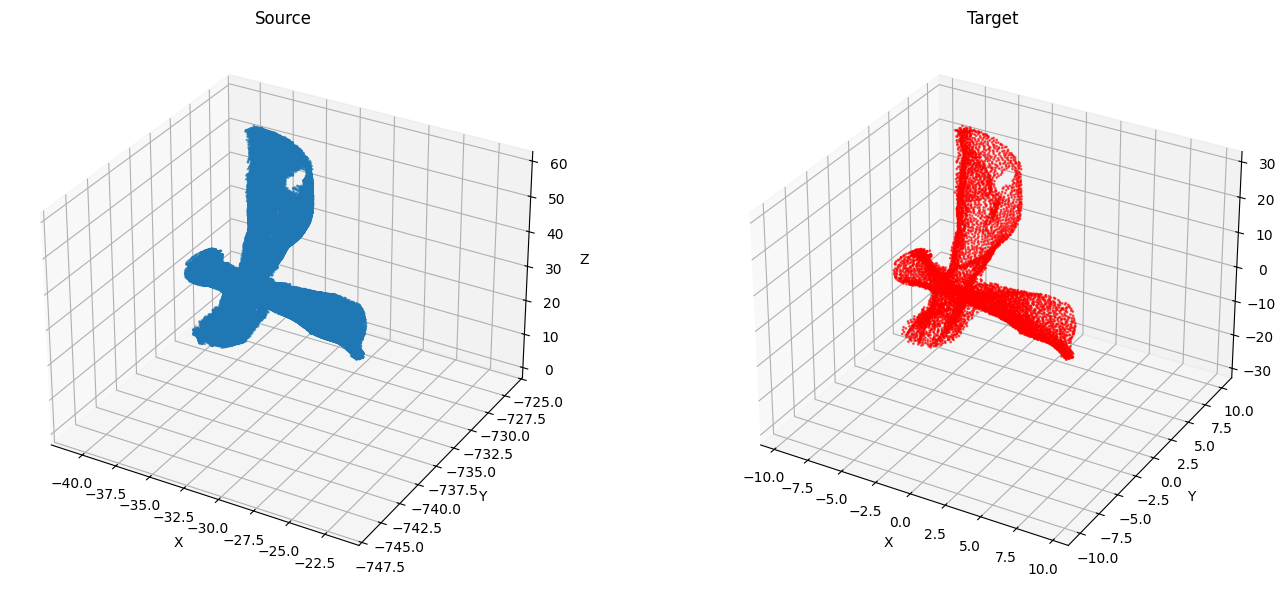

In [18]:
visualize_point_clouds_side_by_side(source_scan_xyz, target_scan_xyz)

We want to translate the points from the 4DPlantReg scans to their respective scans in TrackPlant3D space. Looking at the point clouds it seems to be just a translation so we try to estimate the translation vector.

### Centroid translation

We try first with a simple centroid-to-centroid translation.

In [19]:
# Eval functions
def chamfer_distance(pc1, pc2):
    """
    Compute the symmetric Chamfer distance between two point clouds.
    Args:
        pc1: numpy array of shape (N, 3)
        pc2: numpy array of shape (M, 3)
    Returns:
        chamfer: float
    """
    kdtree1 = cKDTree(pc1)
    kdtree2 = cKDTree(pc2)
    dist1, _ = kdtree2.query(pc1, k=1)
    dist2, _ = kdtree1.query(pc2, k=1)
    chamfer = np.mean(dist1) + np.mean(dist2)
    return chamfer

def evaluate_registration(transformed_points, target_points):
    """
    Evaluate registration quality by computing mean distance to nearest neighbors and Chamfer distance.

    Args:
        transformed_points: original source points
        target_points: target points

    Returns:
        mean_distance: mean distance from transformed source to nearest target points
        max_distance: maximum distance
        chamfer: symmetric Chamfer distance
    """
    kdtree = cKDTree(target_points)
    distances, _ = kdtree.query(transformed_points, k=1)
    chamfer = chamfer_distance(transformed_points, target_points)
    return np.mean(distances), np.max(distances), chamfer

In [20]:
source_centroid = np.mean(source_scan_xyz, axis=0)
target_centroid = np.mean(target_scan_xyz, axis=0)
translation = target_centroid - source_centroid
translation

array([ 30.00085317, 737.97805223, -32.46911471])

In [21]:
aligned_source_xyz = source_scan_xyz.copy()
aligned_source_xyz[:, :3] += translation
aligned_source_xyz

array([[ -8.58304683,   7.91965223, -29.52831471],
       [ -8.65234683,   7.91855223, -29.53871471],
       [ -8.71024683,   7.89595223, -29.56991471],
       ...,
       [ -9.23474683,   4.97895223, -31.27231471],
       [ -9.14204683,   4.97465223, -31.30251471],
       [ -9.04694683,   4.96465223, -31.32961471]], shape=(230348, 3))

In [22]:
print("Aligned Source XYZ Bounds:")
print("Min:", aligned_source_xyz.min(axis=0))
print("Max:", aligned_source_xyz.max(axis=0))
print("Target XYZ Bounds:")
print("Min:", target_scan_xyz.min(axis=0))
print("Max:", target_scan_xyz.max(axis=0))

Aligned Source XYZ Bounds:
Min: [-10.92374683  -8.42954777 -31.35031471]
Max: [ 8.43075317 11.69925223 25.99968529]
Target XYZ Bounds:
Min: [ -9.62355 -10.0644  -28.6679 ]
Max: [ 9.65365  10.0644   28.674999]


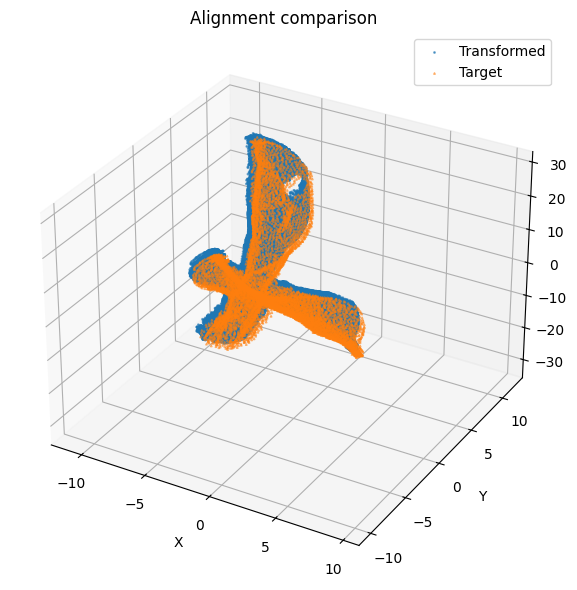

In [23]:
visualize_point_clouds_together(aligned_source_xyz, target_scan_xyz)

In [24]:
centroid_mean_dist, centroid_max_dist, centroid_chamfer = evaluate_registration(
    aligned_source_xyz, target_scan_xyz)
print(f"Centroid translation: {translation}")
print(f"Mean distance: {centroid_mean_dist:.4f}")
print(f"Max distance: {centroid_max_dist:.4f}")
print(f"Chamfer distance: {centroid_chamfer:.4f}")

Centroid translation: [ 30.00085317 737.97805223 -32.46911471]
Mean distance: 0.7854
Max distance: 3.4363
Chamfer distance: 1.5157


In [25]:
# Save file for interactive visualization
combined_pc = np.vstack((aligned_source_xyz, target_scan_xyz))
pcd = o3d.geometry.PointCloud()
target_colors = np.tile([0, 0, 1], (target_scan_xyz.shape[0], 1))  # Blue
source_colors = np.tile([0, 1, 0], (aligned_source_xyz.shape[0], 1))  # Green
pcd.points = o3d.utility.Vector3dVector(combined_pc)
pcd.colors = o3d.utility.Vector3dVector(np.vstack([source_colors, target_colors]))
o3d.io.write_point_cloud("example_aligned_pointclouds_centroid_translation.ply", pcd)

True

The alignment is not great, maybe due to the difference in point cloud density, so we need to improve the translation. Next we try Iterative Closest Point (ICP), but just optimize the translation component.

### ICP translation

This does the same as the centroid to centroid translation above, but it does so iteratively minimizing the mean squared distance of each transformed point to its nearest neighbor in the target point cloud (one-sided squared chamfer distance).

In [26]:
# Helper functions
def rigid_registration_translation_only(
    source_points, target_points, max_iterations=200, tolerance=1e-6
):
    """
    Rigid registration finding optimal translation between two point clouds.
    Assumes rotation is already aligned, only estimates translation.

    Args:
        source_points: numpy array of shape (N, 3) - smaller point cloud
        target_points: numpy array of shape (M, 3) - larger point cloud
        max_iterations: maximum number of ICP iterations
        tolerance: convergence tolerance for translation change

    Returns:
        translation: optimal translation vector (3,)
        final_error: final mean squared error
        iterations: number of iterations used
    """

    source = np.array(source_points, dtype=np.float64)
    target = np.array(target_points, dtype=np.float64)

    print("Max iterations:", max_iterations)

    # Initialize translation to zero
    translation = np.zeros(3)
    prev_error = float("inf")

    # Build KD-tree for fast nearest neighbor search on larger target cloud
    kdtree = cKDTree(target)

    for iteration in range(max_iterations):
        # Apply current translation to source points
        transformed_source = source + translation

        # Find nearest neighbors in target for each transformed source point
        distances, indices = kdtree.query(transformed_source, k=1)
        closest_target_points = target[indices]

        # Calculate current mean squared error
        current_error = np.mean(distances**2)

        # Check for convergence
        if abs(prev_error - current_error) < tolerance:
            print(
                f"Change in error is less than tolerance: {abs(prev_error - current_error)} < {tolerance}. Stopping optimization",
            )
            break

        # Compute optimal translation using centroids
        # The optimal translation minimizes sum of squared distances
        source_centroid = np.mean(transformed_source, axis=0)
        target_centroid = np.mean(closest_target_points, axis=0)

        # Update translation
        translation_update = target_centroid - source_centroid
        translation += translation_update

        prev_error = current_error

        # Early stopping if translation update is very small
        if np.linalg.norm(translation_update) < tolerance:
            print(
                f"Norm of translation update lower than tolerance: {np.linalg.norm(translation_update)} < {tolerance}. Stopping optimization",
            )
            break

    return translation, current_error, iteration + 1

In [27]:
translation, final_error, iters = rigid_registration_translation_only(source_scan_xyz, target_scan_xyz)
transformed_source_xyz = source_scan_xyz + translation

Max iterations: 200
Change in error is less than tolerance: 8.710187742004549e-07 < 1e-06. Stopping optimization


In [28]:
print("Transformed Source XYZ Bounds:")
print("Min:", transformed_source_xyz.min(axis=0))
print("Max:", transformed_source_xyz.max(axis=0))
print("Target XYZ Bounds:")
print("Min:", target_scan_xyz.min(axis=0))
print("Max:", target_scan_xyz.max(axis=0))

Transformed Source XYZ Bounds:
Min: [ -9.68178423 -10.07704126 -28.68261065]
Max: [ 9.67271577 10.05175874 28.66738935]
Target XYZ Bounds:
Min: [ -9.62355 -10.0644  -28.6679 ]
Max: [ 9.65365  10.0644   28.674999]


In [29]:
icp_mean_dist, icp_max_dist, icp_chamfer = evaluate_registration(transformed_source_xyz, target_scan_xyz)
print(f"ICP translation: {translation}")
print(f"Final MSE: {final_error:.4f}")
print(f"Mean distance: {icp_mean_dist:.4f}")
print(f"Max distance: {icp_max_dist:.4f}")
print(f"Chamfer distance: {icp_chamfer:.4f}")
print(f"Converged in {iters} iterations")

ICP translation: [ 31.24281577 736.33055874 -29.80141065]
Final MSE: 0.0233
Mean distance: 0.1424
Max distance: 0.3387
Chamfer distance: 0.1772
Converged in 99 iterations


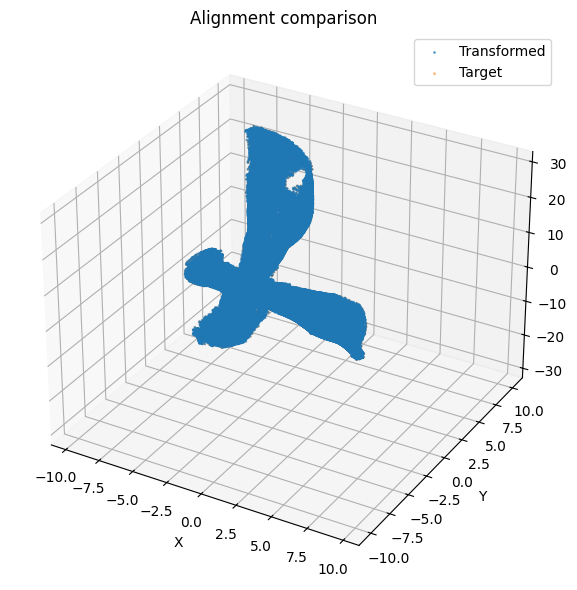

In [30]:
visualize_point_clouds_together(transformed_source_xyz, target_scan_xyz)

In [31]:
# Save transformed source point cloud
combined_pc = np.vstack([transformed_source_xyz, target_scan_xyz])
target_colors = np.tile([0, 0, 1], (target_scan_xyz.shape[0], 1))  # Blue
source_colors = np.tile([0, 1, 0], (transformed_source_xyz.shape[0], 1))  # Green
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(combined_pc)
pcd.colors = o3d.utility.Vector3dVector(np.vstack([source_colors, target_colors]))
o3d.io.write_point_cloud("aligned_and_target_ICP.ply", pcd)

True

### Batch process all pairs

In [ ]:
def align_all_pairs(source_files: list[str], target_files: list[str], save_combined: bool = False, save_path: Optional[Path] = None) -> dict:
    """
    Align source points to target points in batches using ICP.
    """
    save_path = Path(save_path) if isinstance(save_path, str) else save_path
    save_path.mkdir(parents=True, exist_ok=True) if save_path else None
    results_report = {}
    for source_path, target_path in zip(source_files, target_files):
        source, _ = load_point_cloud_from_txt(source_path)
        target, _ = load_point_cloud_from_txt(target_path)

        print(f"Aligning: {source_path} -> {target_path}")
        translation, final_error, iters = rigid_registration_translation_only(source, target)
        transformed_source = source + translation
        icp_mean_dist, icp_max_dist, icp_chamfer = evaluate_registration(transformed_source, target)
        results_report[Path(target_path).name] = {
            "source_path": str(source_path).strip("../"),
            "final_error": float(final_error),
            "iterations": int(iters),
            "icp_mean_dist": float(icp_mean_dist),
            "icp_max_dist": float(icp_max_dist),
            "icp_chamfer": float(icp_chamfer),
            "translation": translation.tolist(),
        }

        # Saved combined point cloud for verification
        if save_combined:
            combined_pc = np.vstack([transformed_source, target])
            target_colors = np.tile([0, 0, 1], (target.shape[0], 1))  # Blue
            source_colors = np.tile([0, 1, 0], (transformed_source.shape[0], 1))  # Green
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(combined_pc)
            pcd.colors = o3d.utility.Vector3dVector(np.vstack([source_colors, target_colors]))
            o3d.io.write_point_cloud(f"{save_path}/{target_path.stem}_and_dense_pair.ply", pcd)


    # Save report
    with open(f"{save_path}/alignment_results.json", "w") as f:
        json.dump(results_report, f)
    
    return results_report

In [55]:
align_all_pairs(maize_paths_4dplantreg+tomato_paths_4dplantreg, maize_paths_trackplant3d, save_combined=True, save_path=Path("../output_temp/plant_gt_alignment/maize"))
align_all_pairs(tomato_paths_4dplantreg, tomato_paths_trackplant3d, save_combined=True, save_path=Path("../output_temp/plant_gt_alignment/tomato"))

Aligning: ../data/4d_plant_registration_data/tomato/plant1/03-05.txt -> ../data/TrackPlant3D/gt_corrected_v1/tomato/352_tomato2_control_plant1_D00.txt
Max iterations: 200
Change in error is less than tolerance: 8.830958050168314e-07 < 1e-06. Stopping optimization


{'352_tomato2_control_plant1_D00.txt': {'source_path': 'data/4d_plant_registration_data/tomato/plant1/03-05.txt',
  'final_error': 0.05473287979202757,
  'iterations': 149,
  'icp_mean_dist': 0.09315039235794284,
  'icp_max_dist': 8.763337273104103,
  'icp_chamfer': 0.13883636126165633,
  'translation': [52.338248338960476, 745.360607364264, -15.567011474429393]}}

By inspecting them visually, we can see the alignment is good!

Finally, we need to propagate the organ semantic instance label to the dense point cloud.

### Propagating semantic labels

We first apply the rigid transformation, then get the nearest neighbour of each target (sparse) point cloud on the source (dense) point cloud, copy their labels and propagate them within the dense point cloud again by nearest neighbour.

In [58]:
translation, final_error, iters = rigid_registration_translation_only(source_scan_xyz, target_scan_xyz)
transformed_source_xyz = source_scan_xyz + translation

Max iterations: 200
Change in error is less than tolerance: 8.710187742004549e-07 < 1e-06. Stopping optimization


In [61]:
def transfer_semantic_labels_knn(
    source_points,
    target_points,
    target_labels,
    k=1,
    max_distance=None,
    default_label=0,
):
    """
    Transfer semantic labels from labeled target cloud to unlabeled source cloud.
    We stay consistent with the terminology used for alignment where the target is
    the small labeled point cloud. Uses nearest neighbor to assign labels.

    Args:
        source_points: numpy array (N,) - unlabeled point cloud (larger, e.g., 250k)
        target_points: numpy array (M, 3) - labeled point cloud (smaller, e.g., 10k)
        target_labels: numpy array (N,) - semantic labels for target points
        k: int - number of nearest neighbors to consider (1 for closest, >1 for voting)
        max_distance: float - maximum distance to consider for labeling (None = no limit)
        default_label: int/str - label for points too far from any source point

    Returns:
        target_labels: numpy array (M,) - predicted labels for target points
        distances: numpy array (M,) - distance to nearest labeled point
    """

    # Build KD-tree on the smaller labeled cloud for efficiency
    kdtree = cKDTree(target_points)

    if k == 1:
        # Simple nearest neighbor
        distances, indices = kdtree.query(source_points, k=1)
        source_labels = target_labels[indices]
    else:
        raise NotImplementedError(
            "k > 1 not implemented yet, we recommend using 1 neighbor to avoid ambiguity"
        )

    # Apply distance threshold if specified
    if max_distance is not None:
        far_mask = distances > max_distance
        target_labels[far_mask] = default_label
        print(
            f"Set {np.sum(far_mask)} points to default label (too far from labeled points)"
        )

    return source_labels, distances

In [62]:
predicted_labels, distances = transfer_semantic_labels_knn(transformed_source_xyz, target_scan_xyz, target_scan_labels)

In [66]:
predicted_labels.shape
target_scan_labels.shape


(10000, 1)

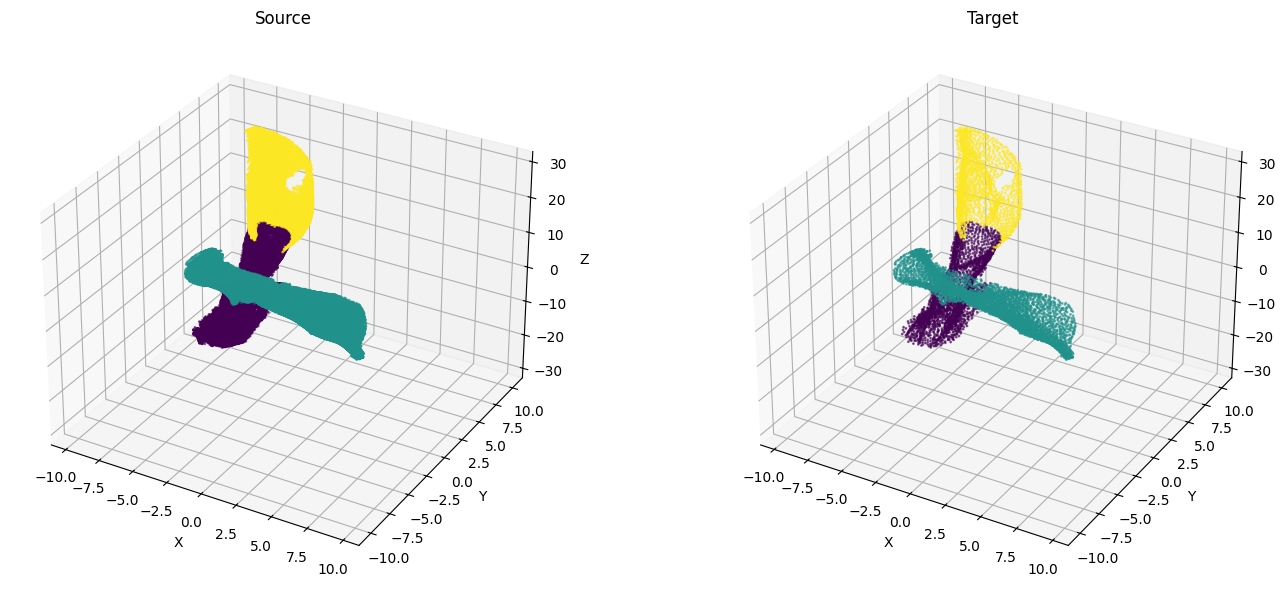

In [68]:
visualize_point_clouds_side_by_side(transformed_source_xyz, target_scan_xyz, labels1=predicted_labels.squeeze().tolist(), labels2=target_scan_labels.squeeze().tolist())

### Final batch process of all pairs including labels

In [75]:
def process_all_pairs(source_files: list[str], target_files: list[str], save_path: str | Path ) -> dict:
    """
    Align source points to target points in batches using ICP. Followed by evaluation and transfering of semantic labels.
    """
    save_path = Path(save_path) if isinstance(save_path, str) else save_path
    save_path.mkdir(parents=True, exist_ok=True) if save_path else None
    results_report = {}
    for source_path, target_path in zip(source_files, target_files):
        target_file_name = Path(target_path).name
        source_points, _ = load_point_cloud_from_txt(source_path)
        target_points, target_labels = load_point_cloud_from_txt(target_path)

        # Find and perform transformation
        print(f"Aligning: {source_path} -> {target_path}")
        translation, final_error, iters = rigid_registration_translation_only(source_points, target_points)
        transformed_source = source_points + translation
        
        # Evaluate registration
        icp_mean_dist, icp_max_dist, icp_chamfer = evaluate_registration(transformed_source, target_points)

        save_file_path = save_path / target_file_name
        results_report[target_file_name] = {
            "file_path": str(save_file_path).strip("../"),
            "source_path": str(source_path).strip("../"),
            "reference_path": str(target_path).strip("../"),
            "final_error": float(final_error),
            "iterations": int(iters),
            "icp_mean_dist": float(icp_mean_dist),
            "icp_max_dist": float(icp_max_dist),
            "icp_chamfer": float(icp_chamfer),
            "translation": translation.tolist(),
        }

        # Transfer semantic labels
        predicted_labels, _ = transfer_semantic_labels_knn(transformed_source, target_points, target_labels)

        # Save transformed file with labels
        np.savetxt(save_file_path, np.hstack([transformed_source, predicted_labels]), fmt="%f %f %f %d")

        break

    # Save report
    report_name = "alignment_results.json"
    if (save_path.parent / report_name).exists():
        with open(f"{save_path.parent / report_name}", "r") as f:
            existing_report = json.load(f)
            results_report = {**existing_report, **results_report}

    with open(save_path.parent / report_name, "w") as f:
        json.dump(results_report, f)
    
    return results_report

In [76]:
process_all_pairs(maize_paths_4dplantreg+tomato_paths_4dplantreg, maize_paths_trackplant3d, save_path=Path("../data/TrackPlant3D/dense/maize"))
process_all_pairs(tomato_paths_4dplantreg, tomato_paths_trackplant3d, save_path=Path("../data/TrackPlant3D/dense/tomato"))

Aligning: ../data/4d_plant_registration_data/maize/plant1/03-13.txt -> ../data/TrackPlant3D/gt_corrected_v1/maize/1_maize_control_plant1_D00.txt
Max iterations: 200
Change in error is less than tolerance: 8.710187742004549e-07 < 1e-06. Stopping optimization
Aligning: ../data/4d_plant_registration_data/tomato/plant1/03-05.txt -> ../data/TrackPlant3D/gt_corrected_v1/tomato/352_tomato2_control_plant1_D00.txt
Max iterations: 200
Change in error is less than tolerance: 8.830958050168314e-07 < 1e-06. Stopping optimization


{'1_maize_control_plant1_D00.txt': {'file_path': 'data/TrackPlant3D/dense/maize/1_maize_control_plant1_D00.txt',
  'source_path': 'data/4d_plant_registration_data/maize/plant1/03-13.txt',
  'reference_path': 'data/TrackPlant3D/gt_corrected_v1/maize/1_maize_control_plant1_D00.txt',
  'final_error': 0.023257837386096433,
  'iterations': 99,
  'icp_mean_dist': 0.14243492956119988,
  'icp_max_dist': 0.33872701195588933,
  'icp_chamfer': 0.17715234223118168,
  'translation': [31.24281577027352, 736.3305587446038, -29.801410647542056]},
 '352_tomato2_control_plant1_D00.txt': {'file_path': 'data/TrackPlant3D/dense/tomato/352_tomato2_control_plant1_D00.txt',
  'source_path': 'data/4d_plant_registration_data/tomato/plant1/03-05.txt',
  'reference_path': 'data/TrackPlant3D/gt_corrected_v1/tomato/352_tomato2_control_plant1_D00.txt',
  'final_error': 0.05473287979202757,
  'iterations': 149,
  'icp_mean_dist': 0.09315039235794284,
  'icp_max_dist': 8.763337273104103,
  'icp_chamfer': 0.13883636126